# Machine Learning Model on Refugee Population Forecasting and Humanitarian Resource Planning System for Kenya
___
**Team**: XG BOOST BUSTERS  
**Contributors**: Cynthia Jemutai, Stephen Jilani, Charity Nduati,Joy Ngeru , Chris Karagu , Sylvia  Wambui

**Project**: Phase 5 Capstone Project   
**Data Sources**: [Kenya Refugee and Asylum Population Dataset](https://www..com/)
___

### 1. Introduction

Kenya accommodates populations displaced by conflict, persecution, climate shocks, and political instability originating from across the region including Somalia, South Sudan, the Democratic Republic of Congo, Ethiopia, Burundi, and Rwanda, among 39 origin countries identified in this dataset.

Several organizations work together to support refugees in Kenya:
1. Department of Refugee Services (DRS): The Kenyan government agency responsible for refugee registration, camp management, policy implementation, and ensuring compliance with the Refugee Act of 2021.
2. United Nations High Commissioner for Refugees (UNHCR): Coordinates the overall refugee response, manages refugee registration and data, mobilizes international funding, and promotes refugee protection.
3. World Food Programme (WFP): Provides food assistance through food distribution and Cash and Voucher Assistance (CVA) programmes to improve food security.
4. Kenya Red Cross Society (KRCS): Delivers frontline humanitarian services, including emergency medical care, disaster response, water supply, family tracing, and support for new refugee arrivals at border entry points.

Together, these organizations form an integrated humanitarian system that provides protection, food, healthcare, and essential services to refugees across Kenya.

### 2. Problem Statement

Kenya hosts one of the largest refugee populations in sub-Saharan Africa, making effective humanitarian planning essential. However, resource planning is often based on current or historical population data rather than future forecasts, limiting preparedness for sudden increases in refugee arrivals.

Key challenges identified from the HDX HAPI dataset include:

1. Rapid population changes that increase demand for food, healthcare, shelter, and other essential services.
2. Diverse demographic groups with different ages, genders, and vulnerabilities that require tailored support.
3. Different population categories (e.g., refugees and asylum seekers) with distinct humanitarian needs.
4. Delays in resource deployment, making it difficult to respond quickly to population surges.
5. Limited use of historical data for forecasting despite decades of available records.

These challenges highlight the need for a machine learning-based forecasting approach to support better resource planning and decision-making for refugee assistance in Kenya.

### 3. Project Objectives

#### 3.1 Primary Objective


To design, develop, and validate a machine learning forecasting system that predicts Kenya's refugee and asylum-seeker population levels disaggregated by origin country, population group, gender, and age cohort with a forecasting horizon of 6 to 24 months, and to translate these forecasts into quantified humanitarian resource planning recommendations.

#### 3.2 Specific Objectives 


1. Explore the HDX HAPI Kenya dataset to identify population trends, demographic patterns, and changes over time.
2. Create relevant features to improve forecasting performance.
3. Develop and compare forecasting models to predict refugee population trends.
4. Generate population forecasts by refugee category, age, gender, and country of origin.
5. Estimate humanitarian resource needs based on the forecasted population.
6. Evaluate model performance using standard forecasting metrics (RMSE, MAE, and MAPE).
7. Provide recommendations to support data-driven humanitarian planning and decision-making in Kenya.

### Data Understanding


The HDX HAPI dataset covers 25 years (2001–2025) with 27,664 records across four population groups: Refugees (REF), Asylum Seekers (ASY), Host Community (HST), and Others of Concern (OOC) disaggregated by gender and five age cohorts.
population count.
les



*Target Variable*
Population
The total refugee/asylum population count.

## 4. Loading of Data  and relevant Libraries

In [21]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
#load data
df = pd.read_csv("Kenya_Refugee.csv")
df.head()

,origin_location_code,origin_has_hrp,origin_in_gho,asylum_location_code,asylum_has_hrp,asylum_in_gho,population_group,gender,age_range,min_age,max_age,population,reference_period_start,reference_period_end
0,AFG,True,True,KEN,False,True,ASY,f,0-4,0.0,4.0,0,2020-01-01,2020-12-31
1,AFG,True,True,KEN,False,True,ASY,f,5-11,5.0,11.0,0,2020-01-01,2020-12-31
2,AFG,True,True,KEN,False,True,ASY,f,12-17,12.0,17.0,0,2020-01-01,2020-12-31
3,AFG,True,True,KEN,False,True,ASY,f,18-59,18.0,59.0,0,2020-01-01,2020-12-31
4,AFG,True,True,KEN,False,True,ASY,f,60+,60.0,NaN,0,2020-01-01,2020-12-31


## Data overview

In [3]:
#total rows and columns
df.shape

(27664, 14)

In [4]:
#list columns
df.columns.tolist()

['origin_location_code',
 'origin_has_hrp',
 'origin_in_gho',
 'asylum_location_code',
 'asylum_has_hrp',
 'asylum_in_gho',
 'population_group',
 'gender',
 'age_range',
 'min_age',
 'max_age',
 'population',
 'reference_period_start',
 'reference_period_end']

*dataset has 27,664 rows and 15 columns*

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27664 entries, 0 to 27663
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   origin_location_code    27664 non-null  object 
 1   origin_has_hrp          27664 non-null  bool   
 2   origin_in_gho           27664 non-null  bool   
 3   asylum_location_code    27664 non-null  object 
 4   asylum_has_hrp          27664 non-null  bool   
 5   asylum_in_gho           27664 non-null  bool   
 6   population_group        27664 non-null  object 
 7   gender                  27664 non-null  object 
 8   age_range               27664 non-null  object 
 9   min_age                 21280 non-null  float64
 10  max_age                 17024 non-null  float64
 11  population              27664 non-null  int64  
 12  reference_period_start  27664 non-null  object 
 13  reference_period_end    27664 non-null  object 
dtypes: bool(4), float64(2), int64(1), obje

*dataset has a mix of categorical and numerical data*
*we notice no missing values*

# Descriptive statistics 

In [6]:
df.describe()

,min_age,max_age,population
count,21280.00000,17024.00000,27664.000000
mean,19.00000,22.75000,1409.757591
std,21.39209,21.42929,13881.284560
min,0.00000,4.00000,0.000000
25%,5.00000,9.25000,0.000000
50%,12.00000,14.00000,0.000000
75%,18.00000,27.50000,17.000000
max,60.00000,59.00000,517666.000000


## 5. Data Cleaning

In [7]:

#filtering the data set to have only data  for refugees who took  assylum in kenya
df = df[df['asylum_location_code']=='KEN']
df

,origin_location_code,origin_has_hrp,origin_in_gho,asylum_location_code,asylum_has_hrp,asylum_in_gho,population_group,gender,age_range,min_age,max_age,population,reference_period_start,reference_period_end
0,AFG,True,True,KEN,False,True,ASY,f,0-4,0.0,4.0,0,2020-01-01,2020-12-31
1,AFG,True,True,KEN,False,True,ASY,f,5-11,5.0,11.0,0,2020-01-01,2020-12-31
2,AFG,True,True,KEN,False,True,ASY,f,12-17,12.0,17.0,0,2020-01-01,2020-12-31
3,AFG,True,True,KEN,False,True,ASY,f,18-59,18.0,59.0,0,2020-01-01,2020-12-31
4,AFG,True,True,KEN,False,True,ASY,f,60+,60.0,NaN,0,2020-01-01,2020-12-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27659,ZWE,False,False,KEN,False,True,REF,m,12-17,12.0,17.0,0,2025-01-01,2025-12-31
27660,ZWE,False,False,KEN,False,True,REF,m,18-59,18.0,59.0,0,2025-01-01,2025-12-31
27661,ZWE,False,False,KEN,False,True,REF,m,60+,60.0,NaN,0,2025-01-01,2025-12-31
27662,ZWE,False,False,KEN,False,True,REF,m,all,NaN,NaN,8,2025-01-01,2025-12-31


In [8]:
#missing values
print('Missing values per column:')
print(df.isnull().sum())
print('\n')
#duplicate 
print('Duplicate :', df.duplicated().sum())

Missing values per column:
origin_location_code         0
origin_has_hrp               0
origin_in_gho                0
asylum_location_code         0
asylum_has_hrp               0
asylum_in_gho                0
population_group             0
gender                       0
age_range                    0
min_age                   2562
max_age                   4270
population                   0
reference_period_start       0
reference_period_end         0
dtype: int64


Duplicate : 0


In [9]:
#we noticed that the all column was a  addition of the males and female which would lead to duplication
#drop 'all' on gender
df = df[df['gender'] != 'all']
print(df['gender'].unique())

['f' 'm']


The removal of the aggregated 'all' category ensures that subsequent analyses will focus on meaningful gender-specific population distributions.

In [13]:
# Display the unique age range categories in the dataset
df['age_range'].unique()

array(['0-4', '5-11', '12-17', '18-59', '60+', 'all'], dtype=object)

The age range variable contains six demographic groups: 0–4, 5–11, 12–17,  18–59 , 60+ years and all (for ages that are not defined). 

In [11]:
df['age_range'].value_counts()

age_range
0-4      1708
5-11     1708
12-17    1708
18-59    1708
60+      1708
all      1708
Name: count, dtype: int64

In [15]:
#checking distribution
df['population'].describe()

count     10248.000000
mean       2399.913447
std       13566.645249
min           0.000000
25%           0.000000
50%           8.000000
75%         236.250000
max      260843.000000
Name: population, dtype: float64

In [17]:
# Examine the distribution of zero population values across population groups
df[df['population'] == 0]['population_group'].value_counts()

population_group
ASY    2251
REF    1627
OOC     148
HST      68
Name: count, dtype: int64

The zero values will be retained because they appear across several population groups and may represent legitimate instances where no individuals were recorded during a reporting period.

In [18]:
# Examine the distribution of zero population values across gender categories
df[df['population'] == 0]['gender'].value_counts()

gender
f    2183
m    1911
Name: count, dtype: int64

Zero population values are relatively evenly distributed between female and male categories. This suggests that the occurrence of zeros is not biased toward a particular gender and is unlikely to be the result of gender-specific reporting errors. No action will be taken on the basis of gender distribution, and the zero values will be retained for further analysis.

In [19]:
# Examine the distribution of zero population values across age groups
df[df['population'] == 0]['age_range'].value_counts()

age_range
60+      1017
0-4       852
12-17     733
5-11      728
18-59     452
all       312
Name: count, dtype: int64

In [16]:
# Final inspection of the data 
df.head(10)

,origin_location_code,origin_has_hrp,origin_in_gho,asylum_location_code,asylum_has_hrp,asylum_in_gho,population_group,gender,age_range,min_age,max_age,population,reference_period_start,reference_period_end
0,AFG,True,True,KEN,False,True,ASY,f,0-4,0.0,4.0,0,2020-01-01,2020-12-31
1,AFG,True,True,KEN,False,True,ASY,f,5-11,5.0,11.0,0,2020-01-01,2020-12-31
2,AFG,True,True,KEN,False,True,ASY,f,12-17,12.0,17.0,0,2020-01-01,2020-12-31
3,AFG,True,True,KEN,False,True,ASY,f,18-59,18.0,59.0,0,2020-01-01,2020-12-31
4,AFG,True,True,KEN,False,True,ASY,f,60+,60.0,NaN,0,2020-01-01,2020-12-31
5,AFG,True,True,KEN,False,True,ASY,f,all,NaN,NaN,0,2020-01-01,2020-12-31
6,AFG,True,True,KEN,False,True,ASY,m,0-4,0.0,4.0,0,2020-01-01,2020-12-31
7,AFG,True,True,KEN,False,True,ASY,m,5-11,5.0,11.0,0,2020-01-01,2020-12-31
8,AFG,True,True,KEN,False,True,ASY,m,12-17,12.0,17.0,0,2020-01-01,2020-12-31
9,AFG,True,True,KEN,False,True,ASY,m,18-59,18.0,59.0,8,2020-01-01,2020-12-31


C:\Users\Cynthia\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


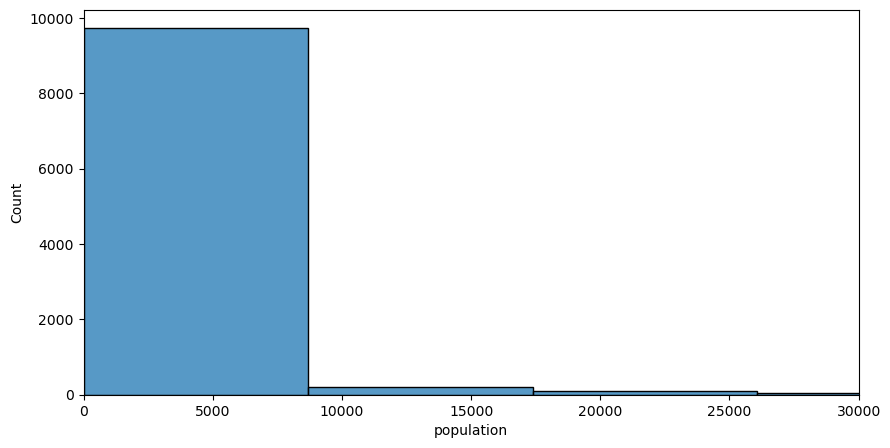

In [22]:
# Visualizing the distribution of population values to assess skewness and identify extreme observations
plt.figure(figsize=(10,5))
sns.histplot(df['population'], bins=30)
#sns.lineplot(df['population'])
plt.xlim(0,30000)
plt.show()